In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [19]:
import pandas as pd

# Paste the URL of the raw CSV file
url = 'https://raw.githubusercontent.com/ELSOUDY2030/Mall-Customers/main/Mall_Customers.csv'

# Read the CSV directly from the web
df = pd.read_csv(url)

# View the first few rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Exploratory Data Analysis

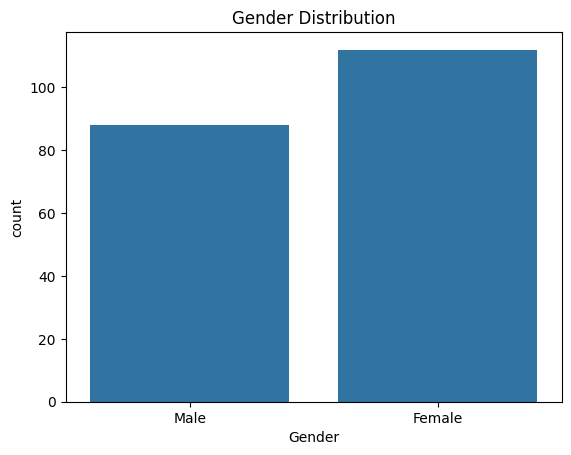

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

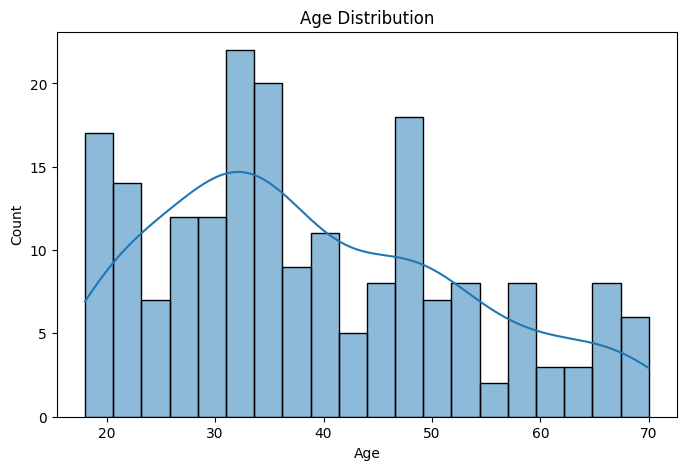

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

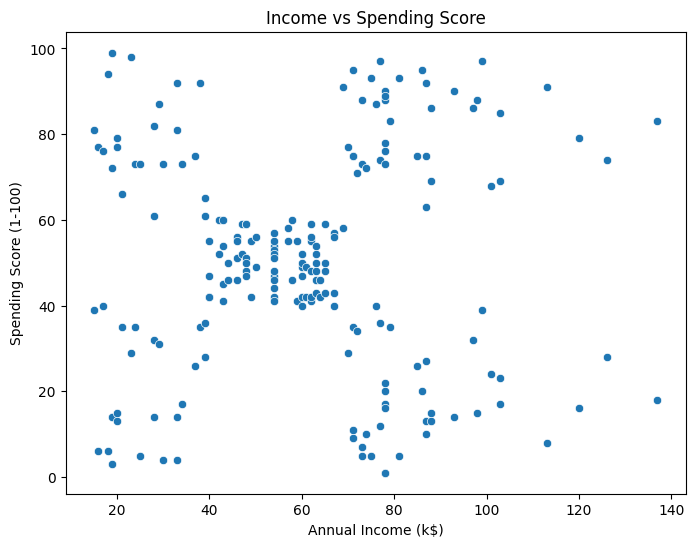

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")

plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


Select Features

In [25]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

Find Optimal Clusters (Elbow Method)

In [26]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

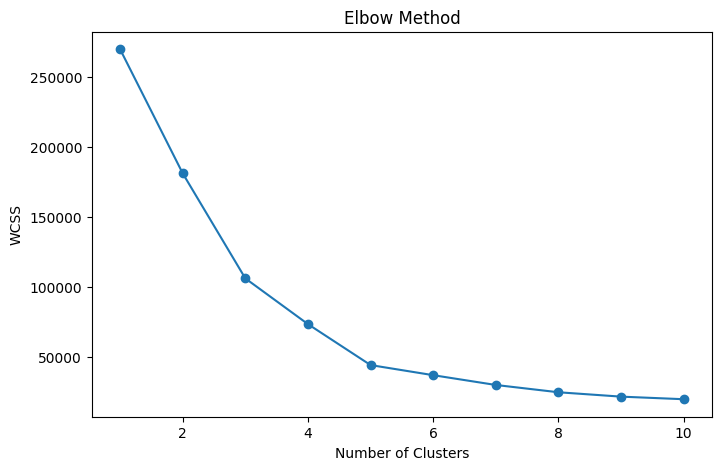

In [27]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

Train K-Means

In [28]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_pred = kmeans.fit_predict(X)

df['Cluster'] = y_pred

Visualize Customer Segments

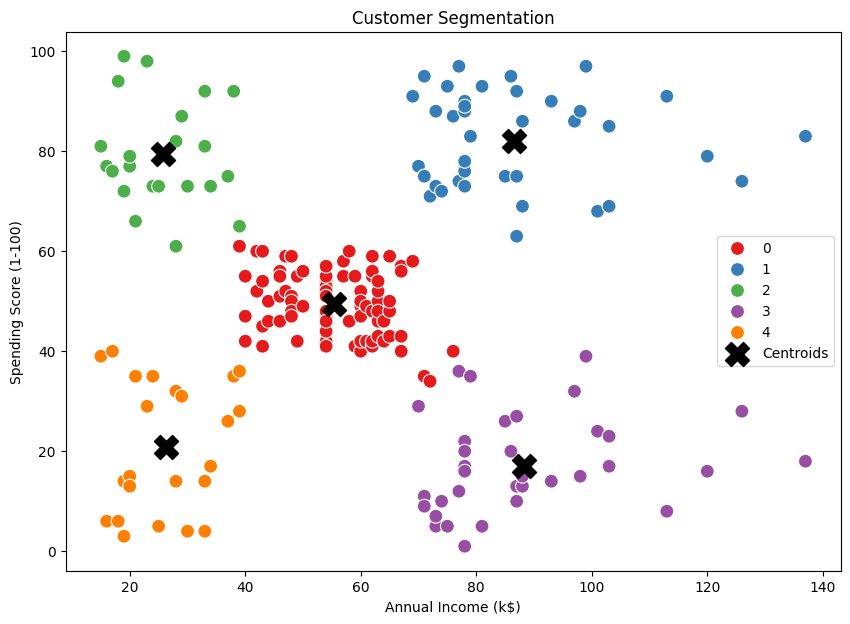

In [29]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation")

plt.legend()

plt.show()

In [30]:
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         86.320988  0.407407  42.716049           55.296296   
1        162.000000  0.461538  32.692308           86.538462   
2         23.090909  0.409091  25.272727           25.727273   
3        164.371429  0.542857  41.114286           88.200000   
4         23.000000  0.391304  45.217391           26.304348   

         Spending Score (1-100)  
Cluster                          
0                     49.518519  
1                     82.128205  
2                     79.363636  
3                     17.114286  
4                     20.913043  


Business Insights

In [31]:
for cluster in sorted(df['Cluster'].unique()):

    print("\nCluster", cluster)

    print(df[df['Cluster']==cluster].describe())


Cluster 0
       CustomerID     Gender        Age  Annual Income (k$)  \
count   81.000000  81.000000  81.000000           81.000000   
mean    86.320988   0.407407  42.716049           55.296296   
std     24.240889   0.494413  16.447822            8.988109   
min     44.000000   0.000000  18.000000           39.000000   
25%     66.000000   0.000000  27.000000           48.000000   
50%     86.000000   0.000000  46.000000           54.000000   
75%    106.000000   1.000000  54.000000           62.000000   
max    143.000000   1.000000  70.000000           76.000000   

       Spending Score (1-100)  Cluster  
count               81.000000     81.0  
mean                49.518519      0.0  
std                  6.530909      0.0  
min                 34.000000      0.0  
25%                 44.000000      0.0  
50%                 50.000000      0.0  
75%                 55.000000      0.0  
max                 61.000000      0.0  

Cluster 1
       CustomerID     Gender        Age  